# Forward vs recurrent connectivity current contribution

This notebook calculates the mean absolute current input to the model units for the feedforward compared to the recurrent connections (Supplementary Figure 2).

In [1]:
import os

import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

from retina import analysis

matplotlib.rcParams["svg.fonttype"] = "none"
matplotlib.rcParams["font.family"] = "Arial"

%load_ext autoreload
%autoreload 2

In [2]:
root = os.path.expanduser("~/PycharmProjects/RetinalModel")

In [3]:
encoding_current_df = analysis.FeedforwardVsRecurrentContribution.get_df(root, prediction_offset=0)
prediction_current_df = analysis.FeedforwardVsRecurrentContribution.get_df(root, prediction_offset=128)

/tmp/ipykernel_2120717/1281586377.py:2: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 6}` instead.

  sns.barplot(data_df, errorbar=("se"), errwidth=6, palette=palette, ax=ax)
/tmp/ipykernel_2120717/1281586377.py:13: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=fs, rotation=45, ha="right")
/tmp/ipykernel_2120717/1281586377.py:2: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 6}` instead.

  sns.barplot(data_df, errorbar=("se"), errwidth=6, palette=palette, ax=ax)
/tmp/ipykernel_2120717/1281586377.py:13: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=fs, rotation=45, ha="right")


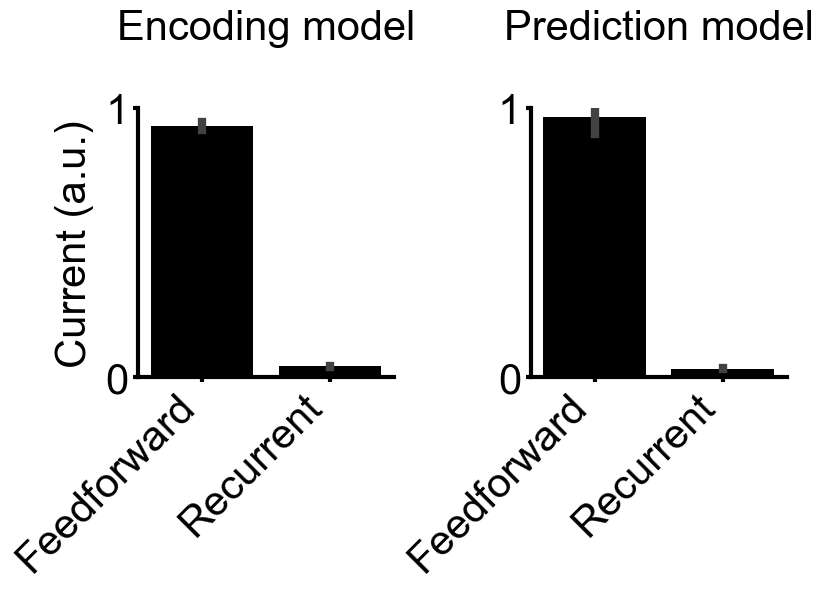

In [4]:
def plot_current_contribution(data_df, y_label, yticks, palette, ax):
    sns.barplot(data_df, errorbar=("se"), errwidth=6, palette=palette, ax=ax)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(3)
    ax.spines["bottom"].set_linewidth(3)
    
    ax.xaxis.set_tick_params(width=3)
    ax.yaxis.set_tick_params(width=3)
    fs = 30
    ax.tick_params(axis="both", which="major", labelsize=fs)
    
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=fs, rotation=45, ha="right")
    ax.set_xlabel("")
    ax.set_ylabel(y_label, fontsize=fs, labelpad=8)
    ax.set_ylim(0, yticks[-1])
    ax.set_yticks(yticks)
    
    ax.legend().set_visible(False)

fig, axs = plt.subplots(1, 2, figsize=(8, 6))
plot_current_contribution(encoding_current_df, "Current (a.u.)", [0, 1], ["black", "black"], ax=axs[0])
plot_current_contribution(prediction_current_df, "Current (a.u.)", [0, 1], ["black", "black"], ax=axs[1])
axs[1].set_ylabel("")
axs[0].set_title("Encoding model", fontsize=30, pad=50)
axs[1].set_title("Prediction model", fontsize=30, pad=50)
fig.tight_layout()
plt.savefig(f"{root}/figures/supp/current_contribution.svg", format="svg", transparent=False, bbox_inches="tight")

In [5]:
U1, p = mannwhitneyu(encoding_current_df["Feedforward"].values, encoding_current_df["Recurrent"].values, alternative="less")
print(p)
U1, p = mannwhitneyu(prediction_current_df["Feedforward"].values, prediction_current_df["Recurrent"].values, alternative="less")
print(p)

1.0
1.0


In [6]:
print(f"% contribution = {100*encoding_current_df['Recurrent'].mean() / (encoding_current_df['Recurrent'].mean() + encoding_current_df['Feedforward'].mean())}")

% contribution = 4.094364556220297
